## Wer wird erwähnt? Personenbezeichnungen im Korpus mithilfe von Wörterbüchern erschließen

Paul ist Computerlinguist und arbeitet in einem interdisziplinären Team mit Kolleg\*innen aus verschiedenen Fachrichtungen, u. a. VWL, Soziologie und Gender Studies.

**Forschungsfrage:**  
Das Forschungsteam möchte untersuchen, wie häufig Männer und Frauen in Zeitungsartikeln erwähnt werden. Dabei sollen sowohl Eigennamen (z. B. _Angela Merkel_) als auch nominale Personenbezeichnungen (z. B. _der Bundeskanzler_) berücksichtigt werden.

**Voraussetzung:**  
Dafür muss Paul ein Korpus aus Zeitungsartikeln mit Fokus auf Personenbezeichnungen aufbauen.

**Herausforderung:**  
In bestehenden Ansätzen wird häufig Named Entity Recognition eingesetzt, die vor allem Eigennamen identifiziert. Eigennamen sind jedoch nur ein Bruchteil aller Personenreferenzen; für eine Gesamtschau darüber, wie Männer und Frauen in Pressetexten dargestellt werden, braucht es auch die Erfassung nominaler Personenbezeichnungen wie _eine Sprecherin_ und ihrer Referenz.
Zudem sind Personenbezeichnungen in Korpora relativ selten (ca. 10%-12% Personenbezeichnungen bei 120,626 Tokens, s. [Müller-Spitzer et al., 2024](https://arxiv.org/pdf/2402.03870)). Eine direkte manuelle Annotation von nicht vorgefilterten Texten wäre daher sehr aufwendig und ineffizient.

**Lexikon-basierter Ansatz:**
Paul nutzt Wörterbücher als Ausgangspunkt, um eine Liste nominaler Personenbezeichnungen zu erstellen. Diese Lemma-Liste dient als Grundlage für gezielte Korpusabfragen, sodass ausschließlich Sätze mit mindestens einer Personenbezeichnung extrahiert werden.

Eine Kollegin macht ihn auf die LexFCS aufmerksam: Dort sind zahlreiche lexikalische Ressourcen, darunter Wörterbücher und Korpora, über einen Aggregator zugänglich.

Der Vorteil für Paul:

- standardisierte Abfragesprachen ([LexCQL](https://zenodo.org/records/15706299) für Wörterbücher und [FCS-QL](https://office.clarin.eu/v/CE-2017-1046-FCS-Specification-v20230426.pdf) für Korpora)
- einheitliches Outputformat
- gleichzeitiger Zugriff auf vielfältige Ressourcen

So kann er effizient eine breite und strukturierte Datengrundlage für weiterführende Analysen aufbauen.


In [1]:
# Import der notwendigen Python-Libraries
from lxml import etree # type: ignore
from IPython.display import display, HTML
import requests
import venn
import re
import json
import html
import matplotlib.pyplot as plt
import pandas as pd

## Überblick zu den aggregierten Ressourcen

Der Aggregator stellt eine große Zahl an Ressourcen bereit. Für Paul ist das zunächst ein Vorteil: Er erhält einen Überblick über die verfügbaren Datenquellen und kann gezielt entscheiden, welche für seine Forschungsfrage relevant sind. Der Aggregator dient hier zur informierten Auswahl geeigneter Ressourcen.

[Unter dieser URL](https://fcs.text-plus.org/rest/init) werden sämtliche Ressourcen der LexFCS aufgelistet. Dort sind auch die entsprechenden Endpunkte dokumentiert, die Paul braucht.  
Eine ausführlichere Beschreibung der verfügbaren Ressourcen findet er zudem in der [Text+ Registry](https://registry.text-plus.org/lexical_resource/search).


In [2]:
def fetch_endpoint_list(aggregator_url='https://fcs.text-plus.org/rest/init'):
    response = requests.get(aggregator_url)
    response.raise_for_status()

    json_response = response.json() # Speichert Response als JSON

    resources = {}

    for resource in json_response.get('resources', []): # Iteriert durch jede aufgelistete Ressource
        resource_id = resource.get('id', []) # Speichert Resource ID für sukzessives Parsing
        if not resource_id:
            continue

        # Extrahiert pro Ressource: Name der Institution, Endpunkt, Landing Page, Name der Ressource
        resources[resource_id] = {
            'Institution': (resource.get('endpointInstitution') or {}).get('name'),
            'Endpoint': (resource.get('endpoint') or {}).get('url'),
            'Landing Page': resource.get('landingPage'),
            'Name': (resource.get('title') or {}).get('de')
        }

    with open(r'endpoints_info.json', 'w', encoding='utf-8') as f:
        json.dump(resources, f, ensure_ascii=False, indent=2) # Speichert Dictionary als .json
    
    print(f"{len(resources)} Endpunkte gefunden und in 'endpoints_info.json' gespeichert.")

fetch_endpoint_list()

603 Endpunkte gefunden und in 'endpoints_info.json' gespeichert.


![Endpoints](https://raw.githubusercontent.com/gmanzone/notebook_plenary/main/endpoints_info.png)

Allerdings bedeutet „mehr Ressourcen“ nicht automatisch „bessere Ergebnisse“. Viele der aufgeführten Ressourcen, etwa Paronymwörterbücher, Sprichwortsammlungen oder fremdsprachige Lexika, liefern für die Abfrage deutscher Personenbezeichnungen keinen Mehrwert.

Deshalb trifft Paul eine bewusste Auswahl: Er beschränkt sich zunächst auf eine gut geeignete Ressource, nämlich _elexiko_, das Online-Wörterbuch zur deutschen Gegenwartssprache.

Dieses Vorgehen hat zwei Vorteile:

- Die Ergebnisse sind inhaltlich konsistent und besser kontrollierbar
- Die Abfragen lassen sich einfacher evaluieren (Precision/Recall)

Die zugehörige Endpunkt-URL für _elexiko_ findet er unter **Endpoint**.


## Endpunkt, Parser, Namespaces

Paul definiert nun die technischen Grundlagen für die API-Abfrage: den Endpunkt, einen XML-Parser und die Namespaces, damit er die strukturierte Antwort später korrekt auslesen kann.


In [3]:
# IDS-Endpunkt
base_url_ids = 'https://www.owid.de/api/fcs/'

# XML-Parser
parser = etree.XMLParser(recover=True) # recover=True zur Behandlung von nicht wohlgeformtem XML

# Dictionary zum Mapping der XML Namespaces beim Parsing.
# Ohne diese Namespaces würde die Suche nach Elementen im XML fehlschlagen,
# weil gleich benannte Tags aus verschiedenen Kontexten unterschieden werden müssen.

ns = {
    'sruResponse': 'http://docs.oasis-open.org/ns/search-ws/sruResponse',
    'fcs': 'http://clarin.eu/fcs/resource',
    'hits': 'http://clarin.eu/fcs/dataview/hits'
}

## Basics zur API und zur Output-Struktur

Zunächst möchte Paul verstehen, wie er mit dem Endpunkt interagieren kann und was dieser ausgibt. Die Operation _explain_ liefert wichtige Erkenntnisse darüber.  
Eine ausführliche Einleitung zur _requests_ Library in Python findet sich [hier](https://realpython.com/python-requests/).


In [4]:
def make_explain_request(url):
    explain_response = requests.get(url, params={
            'operation': 'explain', # 'explain' für Endpunkt-Beschreibung
            'x-fcs-endpoint-description': 'true' # Zeigt ausführliche Endpoint-Beschreibung (inkl. Ressourcendetails)
            })

    try:
        explain_response.raise_for_status()
    except requests.exceptions.HTTPError as http_err:
        print(f'HTTP-Fehler: {http_err}')
    else:
        print("Der Explain-Request war erfolgreich. Die Antwort wurde in explain_response.xml gespeichert.")

    explain_response_content = explain_response.content
    explain_response_root = etree.fromstring(explain_response_content, parser=parser)
    explain_response_tree = etree.ElementTree(explain_response_root)

    explain_response_tree.write(
    'explain_response.xml',
    encoding='utf-8',
    pretty_print=True,
    xml_declaration=True)

make_explain_request(base_url_ids)


Der Explain-Request war erfolgreich. Die Antwort wurde in explain_response.xml gespeichert.


![Endpoint Description](https://raw.githubusercontent.com/gmanzone/notebook_plenary/main/expresponse.png)

Paul schaut sich drei wichtige Bereiche der API Response an.

- **Capabilities**  
  Im Bereich Capabilities finden sich die möglichen Suchmodi für den jeweiligen Endpunkt. In diesem Fall heißt es, dass sowohl die Basic als auch die Advanced Search unterstützt werden

- **Resources**  
  Unter Resources werden sämtliche Ressourcen aufgelistet, die im Endpunkt enthalten sind. An diesem Beispiel wird erkennbar, dass dieser Endpunkt die Abfrage des Wörterbuchs _elexiko_ ermöglicht. Dabei können die lexikalischen Felder im Element _AvailableLexFields_ genutzt werden, um Abfragen zu formulieren

- **SupportedLexFields**  
  Hier werden die Felder aufgeführt, die vom Endpunkt generell unterstützt werden, also sämtliche Features, die ihm ressourcenübergreifend bekannt sind


## Beispiel für eine Advanced Search

Paul führt eine erste Abfrage durch, um sich das Outputformat genauer anzusehen.
Dabei nutzt er die Advanced Search, die über den Parameter `queryType=lex` aktiviert wird.
Sie ermöglicht gezielte Abfragen über strukturierte Informationsfelder eines Eintrags, etwa _Lemma_ oder _Definition_.


In [5]:
response = requests.get(
    base_url_ids,
    params={
        'operation': 'searchRetrieve', # 'searchRetrieve' für Wörterbuchabfrage
        'queryType': 'lex', # 'lex' für Advanced Search, Parameter weglassen für Basic Search
        'query': 'lemma = "Berg"',
        'maximumRecords': 1000,
    },
)
response.raise_for_status()

response_content = response.content
response_root = etree.fromstring(response_content, parser=parser)
response_tree = etree.ElementTree(response_root)

# Schreibt die Response in ein XML-Dokument
response_tree.write(
    'advanced_search_output.xml',
    encoding='utf-8',
    pretty_print=True,
    xml_declaration=True
)

![Advanced Search Output](https://raw.githubusercontent.com/gmanzone/notebook_plenary/main/advanced.png)

Hier ist ein Ausschnitt einer API Response bei einer Advanced Search. In diesem Fall handelt es sich um einen Eintrag, der in der Ressource _elexiko_ gefunden wurde.  
Bei der Advanced Search sind die Ergebnisse pro gematchtem Artikel in zwei verschiedenen Formaten gegliedert:

1. einmal in kondensierter Form in der _hits Data View_ (oben links)
2. und einmal in der _lex Data View_. Dort sind ähnliche Informationen wie in der anderen Data View enthalten, allerdings mit Links (z. B. zu Tagsets oder zum Artikel selbst) angereichert und nach jedem Feld aufgeschlüsselt (unten rechts)


## Boilerplate Code: grundlegend und wiederverwendbar

Da das Output der LexFCS nach einem definierten Schema geliefert wird, kann Paul sich einige Funktionen zurechtlegen, mit denen er gleichermaßen Korpora und Wörterbücher durch die API konsultieren kann.  
Der Code ist relativ einfach zu schreiben und zu verstehen, und der Aufwand ist einmalig. In Zukunft wird er dann nur die gewünschte Query einfügen und schon kann es mit der nächsten Abfrage losgehen. Dank der LexFCS hat er Zugriff nicht nur auf Daten, sondern strukturierte, kombinierbare Suchdimensionen.

Die Pipeline setzt sich aus folgenden Funktionen zusammen:

1. `run_query`: Kapselt die komplette API-Logik für beide Ressourcentypen
2. `get_num_records`: Extrahiert die Gesamtzahl der Treffer aus dem Element _numberOfRecords_. Dies ist besonders nützlich, wenn man mit Pagination arbeiten möchte und den API Limit (Parameter _maximumRecords_) von 1000 Records umgehen möchte
3. `extract_lemmas`/`extract_sentences`: Extrahiert Treffer je nach Ressourcentyp (Wörterbuch/Korpus)
4. `highlight_lemma_in_texts`: Funktion zur Anzeige von Belegen der Korpussuche.


In [6]:
# Fragt Text+-Ressourcen ab
def run_query(url, query, queryType, source=None, max_records=1000, start_record=1, **additional_params):
    if url is None or query is None or queryType is None:
        raise ValueError("Die Parameter 'url', 'query' und 'queryType' sind erforderlich und dürfen nicht None sein.")
    
    if source is not None:
        if isinstance(source, list) and len(source) > 0:
            source = f' AND source={' OR source='.join(source)}'
        elif isinstance(source, str):
            source = f' AND source={source}'
        else:
            raise ValueError("Ungültiger 'source'-Parameter. Bitte übergeben Sie entweder einen String oder eine Liste von Strings.")
        query = f"{query}{source}"

    base_params={
        'operation': 'searchRetrieve',
        'queryType': queryType, # 'lex' für Wörterbuchabfrage, 'fcs' für Korpussuche
        'query': query,
        'maximumRecords': max_records, # In der Regel liegt das Maximum bei 1000
        'startRecord': start_record, # Der Endpunkt liefert nicht alle Records auf einmal, sondern Seiten (Chunks). startRecord gibt den Startindex innerhalb der Trefferliste an
    }
    base_params.update(additional_params)
    
    try:
        response = requests.get(url, params=base_params)
        response.raise_for_status()
    except:
        print(f"Achtung: Der Endpunkt '{url}' hat eine strikte CORS-Policy. Laden Sie das Jupyter-Notebook herunter und führen Sie es lokal aus.")
        return None
    
    return etree.fromstring(response.content, parser=parser)

# Extrahiert die Gesamtzahl der Treffer (im Element numberOfRecords des XML-Dokuments)
def get_num_records(root):
    el = root.find('.//sruResponse:numberOfRecords', namespaces=ns)
    return int(el.text) if el is not None else 0

# Extrahiert Treffer (Wörterbücher)
def extract_lemmas(root):
    lemmas = set()

    records = root.findall('.//sruResponse:record', namespaces=ns)

    for record in records:
        hits = record.findall('.//hits:Hit', namespaces=ns)
        for hit in hits:
            if hit.get('kind') == 'lex-lemma':
                if hit.text:
                    lemmas.add(hit.text)

    return lemmas

# Extrahiert Treffer (Korpora)
def extract_sentences(root):
    sentences = set()

    records = root.findall('.//sruResponse:record', namespaces=ns)

    for record in records:
        results = record.findall('.//hits:Result', namespaces=ns)
        for res in results:
            sentences.add(''.join(res.itertext()))

    return sentences


# Funktion zum Hervorheben von Lemma in den gefundenen Sätzen
def highlight_lemma_in_texts(texts, lemma, max_results=None):
    lbl = "Gefundene Sätze"
    if(max_results is not None):
        texts = list(texts)[:max_results]
        lbl = f"{max_results} Beispiele"
    pattern = re.compile(re.escape(lemma), flags=re.IGNORECASE)
    items = []

    for text in texts:
        if pattern.search(text):
            escaped = html.escape(text)
            highlighted = pattern.sub(
                '<mark style="background: linear-gradient(120deg, #ffe066, #ffaf40); color:#111; padding:0 4px; border-radius:4px;">\\g<0></mark>',
                escaped
            )
            items.append(
                f'<div style="margin:0 0 14px; padding:14px 16px; background:#f9f9fb; border:1px solid #e2e5ec; border-radius:14px; box-shadow:0 6px 14px rgba(0,0,0,0.06); line-height:1.7;">{highlighted}</div>'
            )

    if not items:
        items.append(
            f'<div style="padding:14px 16px; color:#555; font-family:Arial,Helvetica,sans-serif;">Keine Sätze mit dem Lemma <strong>{html.escape(lemma)}</strong> gefunden.</div>'
        )

    html_output = f'''
    <div style="font-family:Arial,Helvetica,sans-serif; color:#222; background-color:#292d3e; padding:10px">
      <h2 style="margin-bottom:12px; color:#fff;">{lbl} für: <span style="background:#22313f; color:#fff; padding:4px 10px; border-radius:10px;">{html.escape(lemma)}</span></h2>
      {''.join(items)}
    </div>
    '''
    display(HTML(html_output))


## Personenbezeichnungen in lexikalischen Ressourcen erfassen: Abfragemöglichkeiten

Paul möchte herausfinden, wie Personenbezeichnungen mithilfe von Wörterbüchern in Korpora systematisch identifiziert werden können, um sie für weiterführende Analysen und Trainingsdaten nutzbar zu machen.

Ein guter Einstieg sind movierte Feminina. Die Movierung (s. [Grammatisches Informationssystem grammis](https://grammis.ids-mannheim.de/systematische-grammatik/2282)) ist ein Vorgang der Wortbildung, bei dem Personenbezeichnungen hinsichtlich des Geschlechts des Referenten spezifiziert werden, meistens mittels Suffigierung auf _-in_ (z. B. _Lehrerin_, _Surferin_). Diese Personenbezeichnungen weisen sowohl formale als auch semantische Muster auf, die sich in der LexFCS gut abfragen lassen: etwa das Suffix selbst, definitorische Hinweise wie _Person_ oder _Mensch_ oder grammatische Merkmale wie das feminine Genus.

Paul probiert also verschiedene Abfragefelder der LexFCS aus. Dabei folgt er einem „Drill-Down“-Prinzip: Er beginnt mit einer eher allgemeinen Abfrage und schränkt diese schrittweise ein, um die Suchqualität gezielt zu steuern.

Die [LexFCS-Seite](https://text-plus.org/daten-dienste/daten/#f%C3%B6derierte-inhaltssuche) ist seine erste Anlaufstelle. Dort findet er schnell Informationen zur Suchsyntax und testet seine Abfragen zunächst in der Benutzeroberfläche, bevor er sie in seinen Code überträgt.

**1. lemma = \*in**  
Es handelt sich um eine rein formale Suche auf Lemma-Ebene. Hier kann man mit einem hohen Recall rechnen, da alle Lemmata gematched werden, die die Sequenz _-in_ enthalten. Das Lemma-Feld ist in jedem Fall vorausgesetzt, weshalb hierfür die meisten Treffer zu erwarten sind. Diese Suche ist zwar für die Abfrage movierter Personenbezeichnungen passend, allerdings wird _-in_ in allen Stellungen eines Lemmas gesucht. Daher werden im Output auch Lemmata mit einbezogen, die keine Personenbezeichnungen sind (z. B. Nomen wie _Verein_ oder Adjektive wie _gemein_).

**2. segmentation = "|rin" OR segmentation = "|tin" OR segmentation = "|gin" OR segmentation = "|min" OR segmentation = "|sin" OR segmentation = "|chin" OR segmentation = "|fin" OR segmentation = "|phin"**  
Das Feld _segmentation_ ermöglicht eine alternative, im Vergleich zu _lemma_ (s. oben) etwas striktere formale Suche. Durch die Angabe der Silbenposition mittels Pipe-Zeichen (|) werden die o. g. unerwünschten Suchtreffer ausgeschlossen, indem der Fokus gezielt auf Movierungssuffixe gerichtet wird. Auch ist dieses Feld besonders nützlich, wenn in einem Wörterbuch inhaltliche Felder wie _definition_ oder grammatische Angaben wie _pos_ oder _gender_ nicht ausreichend dokumentiert sind und man bei der Abfrage auf die formale Ebene angewiesen ist.

**3. lemma = \*in AND pos = NOUN AND (definition = Person OR definition = Mensch OR definition = Frau)**  
Neben der formalen Ebene können die Wortart und die Definition eines Lemmas ebenfalls Hinweise für eine Personenbezeichnung enthalten. Eine solche Erweiterung durch definitorische Kriterien kann auch nicht-movierte Personenbezeichnungen wie _Witwe_ oder _Schwester_ erfassen, allerdings nur, wenn auf die Einschränkung `lemma = *in` verzichtet wird. Alternativ dazu könnte die Abfrage so formuliert werden, dass sie Epikoina oder geschlechtsabstrahierende Personenbezeichnungen wie _Hilfskraft_ oder _Studierende_ matcht (`lemma = *kraft OR lemma = *ende`).

**4. lemma = \*in AND pos = NOUN AND (definition = Person OR definition = Mensch OR definition = Frau) AND gender = Fem**  
Die vorherige Abfrage wird abschließend um die Spezifikation des femininen Genus erweitert.


In [7]:
queries_movierung = {
    'lemma': 'lemma = *in',
    # 1. Formale Lemma-Suche (Welche Lemmata beinhalten die Sequenz '-in'?)

    'segmentation': 'segmentation = "|rin" OR segmentation = "|tin" OR segmentation = "|gin" OR segmentation = "|min" OR segmentation = "|sin" OR segmentation = "|chin" OR segmentation = "|fin" OR segmentation = "|phin"',
    # 2. Fokus auf Movierungsmöglichkeiten auf Grundlage der Silbentrennung (s. Nübling & Rosar, 2025)

    'lemma_pos_definition': 'lemma = *in AND pos = NOUN AND (definition = Person OR definition = Mensch OR definition = Frau)',
    # 3. Erweiterung um Wortart und Definition

    'lemma_pos_definition_gender': 'lemma = *in AND pos = NOUN AND (definition = Person OR definition = Mensch OR definition = Frau) AND gender = Fem',
    # 4. Erweiterung um grammatisches Genus
}

In [8]:
# Für jede formulierte Abfrage wird die Pipeline angewendet

results_movierung = {}
match_count = {}
df = pd.DataFrame(columns=['Abfrage', 'Lemmata'])

for label, query in queries_movierung.items():
    print(f'\n--- Abfrage: {label} -> ', end='')
    root = run_query(base_url_ids, query, "lex", source=['elex'], resource_type='dictionary')
    num_records = get_num_records(root)
    lemmas = extract_lemmas(root)
    results_movierung[label] = lemmas
    match_count[label] = num_records
    df.loc[len(df)] = [label, list(lemmas)]
    print(f'Anzahl der Treffer: {num_records} ---')

df.to_csv('movierte_feminina.csv', index=False)


--- Abfrage: lemma -> Anzahl der Treffer: 7659 ---

--- Abfrage: segmentation -> Anzahl der Treffer: 6899 ---

--- Abfrage: lemma_pos_definition -> Anzahl der Treffer: 32 ---

--- Abfrage: lemma_pos_definition_gender -> Anzahl der Treffer: 29 ---


## Visualisierung der Ergebnisse

Nachdem Paul die Abfragen ausgeführt hat, vergleicht er deren Ergebnisse im Hinblick auf Umfang und Qualität.

- Wie viele Lemmata wurden pro Abfrage gematched?
- Wie ähnlich oder unterschiedlich sind die Matches je nach Query?

Paul analysiert dies anhand von Säulen- und Mengendiagrammen. Dafür nutzt er die Python-Library _matplotlib_.


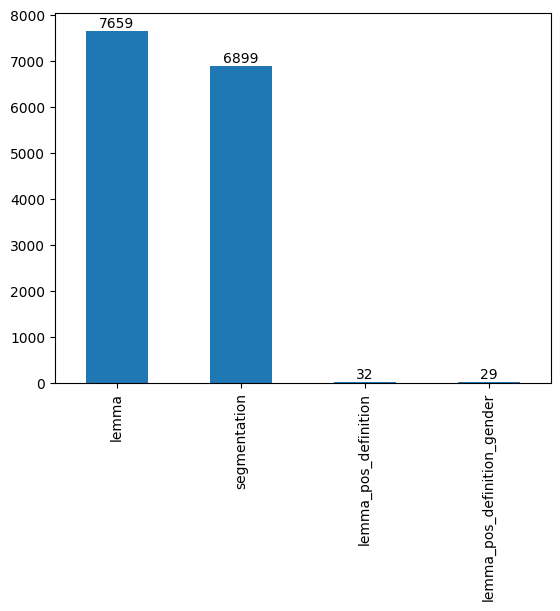

<Figure size 640x480 with 0 Axes>

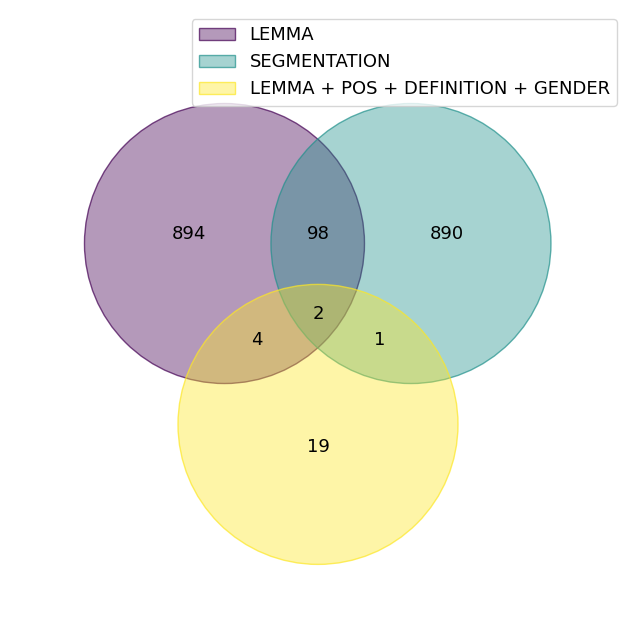

In [9]:
# Visualisiert die Anzahl der Matches pro Abfrage (Säulendiagramm)
def plot_bar(sizes, filename, save_plot=False):
    ax = pd.Series(sizes).plot(kind='bar')
    for i, v in enumerate(sizes.values()):
        ax.text(i, v, str(v), ha='center', va='bottom')
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

# Visualisiert die Anzahl der gemeinsamen Matches unter den verschiedenen Abfragen (Mengendiagramm)
def plot_venn(sets, filename, save_plot=False):
    plt.figure()
    venn.venn(sets)
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

# Exportiert Types pro Abfrage
def export_sets(set1, set2, filename):
    df = pd.DataFrame({
    'union': pd.Series(list(set1 & set2)),
    'only_lemma_query': pd.Series(list(set1 - set2)),
    'only_segmentation_query': pd.Series(list(set2 - set1))
    })
    df.to_csv(filename, index=False)

# Vollständige Pipeline zur Visualisierung
def plot_stats(results, counts):
    sizes = counts

    venn_sets = {
        'LEMMA': set(results['lemma']),
        'SEGMENTATION': set(results['segmentation']),
        'LEMMA + POS + DEFINITION + GENDER': set(results['lemma_pos_definition_gender'])
    }

    set1, set2, set3 = venn_sets.values()

    plot_bar(sizes, filename='matches_per_query.png', save_plot=True)
    plot_venn(venn_sets, filename='venn_plot.png', save_plot=True)
    export_sets(set1, set2, filename='lemma_segmentation_comparison.csv')

    return set1, set2, set3

plot_stats(results_movierung, match_count);

## Ergebnissanalyse

Die API liefert nicht alle Treffer auf einmal zurück, sondern arbeitet mit einer Art Paginierung.
Im XML sieht man zwar die Gesamtzahl der Treffer im Element _numberOfRecords_, pro Anfrage erhält man aber nur eine begrenzte Anzahl zurück (in der Regel bis zu 1.000 Einträge).  
Die Zahlen im ersten Säulendiagramm stehen also für die Gesamtzahl aller Treffer, während die Zahlen im Mengendiagramm für die erste Teilmenge (Chunk) dieser Ergebnisliste stehen.  
Dieses Verhalten ist typisch für viele APIs und wird als [Pagination](https://apidog.com/de/blog/rest-api-pagination-de/) bezeichnet.

Paul analysiert die Ergebnisse der verschiedenen Abfragen. Hier zeigt sich deutlich der klassische Trade-off zwischen Precision und Recall:
Allgemeine Abfragen liefern viele Treffer (hoher Recall), enthalten aber mehr irrelevante Ergebnisse, während spezifischere Abfragen präzisere, aber deutlich weniger Treffer liefern.

- Die Abfrage der Felder _lemma_ und _segmentation_ liefert die meisten Treffer (zwischen 7.000 und 8.000)
- Mit der Erweiterung um _pos_ und _definition_ wird die Rückgabe präziser, allerdings werden nur 31 Matches gefunden mit einigen noch irrelevanten Lemmas (z. B. die Lemmata _Bewusstsein_ oder _Nein_, weil das Token _Person_ in der Definition des Eintrags gematched wurde)
- Die Spezifizierung des grammatischen Genus erzeugt eine saubere Token-Liste. Die Gesamtzahl der Treffer ist hierbei jedoch 28

Eine vielfältige Lemma-Liste ist entscheidend, um eine möglichst breite Abdeckung von Personenbezeichnungen zu erreichen. Nur so lassen sich unterschiedliche Formen und Verwendungskontexte systematisch erfassen.
Daher entscheidet sich Paul, die Ergebnisse der zweiten und vierten Abfrage zusammenzuführen.  
Insgesamt umfasst die Liste rund 7000 unterschiedliche Lemmata, die in verschiedenen Kontexten im Korpus auftreten können. Dies bildet eine solide Grundlage für weiterführende Analysen. Zum Vergleich: In [Sökefeld et al.](https://aclanthology.org/2023.isa-1.5.pdf) (2023) finden sich unter 126.459 Tokens lediglich 3.762 Personenbezeichnungen, davon 1.441 Types.  
Abschließend führt Paul eine manuelle Überprüfung durch, um mögliche False Positives zu entfernen.


## Erschließung neuer Suchmöglichkeiten: Maskulina derivieren

Paul nutzt die vorhandene Lemma-Liste, um neue Suchmöglichkeiten zu erschließen.
Dazu leitet er aus den movierten Feminina potenzielle Stämme ab, indem er das Suffix _-in_ systematisch entfernt.

Um auch Fälle mit Vokalwechsel zwischen Femininum und Maskulinum zu berücksichtigen (_Ärztin_ → _Arzt_), implementiert er die Funktion `generate_variants`. Diese erzeugt für jedes Lemma Varianten ohne Umlaut, die anschließend gegen das Wörterbuch geprüft werden.

Mithilfe von regulären Ausdrücken in der Abfrage (`lemma =/regexp`) kann er seine Liste an movierten Feminina gezielt um passende Maskulina erweitern. Der reguläre Ausdruck ist so gestaltet, dass er nicht nur exakte Stammübereinstimmungen findet, sondern auch Fälle berücksichtigt, in denen der Derivationsstamm noch keinem vollständigen Maskulinum entspricht. Das ist etwa bei Formen wie _Kollegin_ der Fall, bei denen zunächst der Stamm _Kolleg_ identifiziert wird, aus dem dann das Maskulinum _Kollege_ abgeleitet werden kann.


In [10]:
# Entfernt die Endung -in bei jedem Token
def remove_feminine_suffix(df, col_lemma, col_segmentation, output_path, view):

    df = pd.read_csv(df)
    feminine_lemmas = list(df[col_lemma]) + list(df[col_segmentation])

    stemmed_lemmas = []

    for lemma in feminine_lemmas:
        if type(lemma) == str:
            lemma = re.sub(r'in$', '', lemma)
            stemmed_lemmas.append(lemma)
        else:
            continue
    
    df_stemmed = pd.DataFrame({'stemmed_lemmas': pd.Series(stemmed_lemmas)})
    df_stemmed.to_csv(output_path, index=False)

    return list(feminine_lemmas), list(stemmed_lemmas)

feminine_lemmas, stemmed_lemmas = remove_feminine_suffix(df=r'lemma_segmentation_comparison.csv', col_lemma='only_lemma_query', col_segmentation='only_segmentation_query', view='csv', output_path=r'stemmed_lemmas.csv');

masculine_lemmas = set()

# Generiert Varianten zur Berücksichtigung von Vokalwechsel bei Maskulina (z. B. Ärztin -> Arzt)

def generate_variants(term, umlauts):
    variants = set([term])

    for i, char in enumerate(term):
        if char in umlauts.keys():
            new_term = term[:i] + umlauts[char] + term[i+1:]
            variants.add(new_term)

    return variants

masculine_lemmas = set()
test = []

umlauts = {'ä': 'a', 'ü': 'u', 'ö': 'o', 'Ä': 'A', 'Ü': 'U', 'Ö': 'O'}

sample_stems = stemmed_lemmas[:10] # Dauert ca. 15 Minuten - daher zu Demo-Zwecken beschränkt '[:10]'

for stem in sample_stems:
    variants = generate_variants(stem, umlauts)

    for variant in variants:
        query = f'lemma =/regexp "^{variant}[a-zA-ZäöüÄÖÜß]{{0,1}}$"'
        # regEx zur Berücksichtigung von Fällen, in denen der Derivationsstamm noch keinem Maskulinum entspricht (z. B. Kollegin → Kolleg-e)

        root = run_query(base_url_ids, query, "lex")
        num_records = get_num_records(root)
        data = extract_lemmas(root) 

        for token in data:
            if token in feminine_lemmas:
                continue
            else:
                masculine_lemmas.add(token)

print(f'Total masculine lemmas found: {len(masculine_lemmas)}')

masculine_lemmas = list(masculine_lemmas)
feminine_lemmas = list(feminine_lemmas)
print(masculine_lemmas)

df_fem_masc = pd.DataFrame({
    'feminine_lemmas': pd.Series(feminine_lemmas),
    'masculine_lemmas': pd.Series(masculine_lemmas)})
df_fem_masc.to_csv('fem_masc_lemmas.csv', index=False)

Total masculine lemmas found: 5
['Haftrichter', 'Hochschulabsolvent', 'Anpasser', 'Advokat', 'Holsteiner']


## Korpusabfrage

Auf Grundlage der gefundenen Lemmata kann Paul jetzt beliebige Korpora abfragen, etwa das Kernkorpus des Digitalen Wörterbuchs der deutschen Sprache.  
Eine Übersicht zur Syntax der Korpusabfragesprache FCS-QL findet sich [hier](https://korap.ids-mannheim.de/doc/ql/fcsql).  
Je nach gewünschtem Schwerpunkt kann Paul seine Abfragen anpassen:

| Beispielfrage                                                                                    | Query                                   |
| ------------------------------------------------------------------------------------------------ | --------------------------------------- |
| Möchte er allgemein Textstellen extrahieren, die die gefundenen Personenbezeichnungen enthalten? | "Personenbezeichnung"                   |
| Oder gezielt Kontexte untersuchen, in denen diesen Personenbezeichnungen ein Adjektiv vorangeht? | [pos="ADJA"]{1} "Personenbezeichnung"   |
| Oder wo eine Personenbezeichnung von einem finiten Verb gefolgt ist?                             | "Personenbezeichnung" [pos ="VVFIN"]{1} |

Paul kann auch hier die Funktion _make_explain_request_ nutzen, um mehr über die Kapazitäten des Endpunkts zu erfahren. So sieht er u. a., dass er im Korpus das Feld _lemma_ Abfragen kann.

Für jedes Lemma kann Paul nun gezielte Korpusabfragen formulieren.


In [11]:
# BBAW-Endpunkt
base_url_bbaw = 'https://clarin.bbaw.de/fcs/kern'

all_lemmas = masculine_lemmas + feminine_lemmas # type: ignore
print(f'Anzahl aller Lemmata: {len(all_lemmas)}') 

# all_lemmas mit 1862 Abfragen dauert ca. 40 Minuten. Deshalb auf 10 Lemmata (5 Feminina und 5 Maskulina) für Testzwecke limitiert.
sample_lemmas = ['Ärztin', 'Kollege', 'Lehrerin']
lemmas = sample_lemmas

results_corpus = []
for lemma in lemmas:
    query = f'[lemma="{lemma}"]'
    root = run_query(base_url_bbaw, query, "fcs")
    if root is None:
        break
    texts = extract_sentences(root)
    results_corpus.extend(texts)
    highlight_lemma_in_texts(texts, lemma, max_results=5) # Zeigt die ersten 5 Sätze pro Lemma mit Hervorhebung an

df = pd.DataFrame(results_corpus, columns=['sentences'])
df.to_csv('corpus_sentences.csv', index=False)

Anzahl aller Lemmata: 1801


## Ausblick: Nutzungsmöglichkeiten der erzeugten Daten

Bis hierhin hat Paul gezeigt, wie sich mithilfe von Wörterbüchern gezielt ein Korpus mit Personenbezeichnungen zusammenstellen lässt.

Der zentrale Mehrwert liegt in der gezielten Vorselektion: Statt große Mengen unstrukturierter Daten manuell zu annotieren, arbeitet Paul direkt mit relevanten Kontexten. Das reduziert den Aufwand erheblich, insbesondere, da Personenbezeichnungen in allgemeinen Korpora vergleichsweise selten sind.

Diese Datengrundlage eröffnet nun verschiedene weiterführende Analyse- und Anwendungsmöglichkeiten:

- **Quantitative Analyse**  
  Wie viele Frauen, wie viele Männer werden in Zeitungsartikeln der letzten 10 Jahre erwähnt?

- **Qualitative Analyse**  
  Das Forschungsteam kann untersuchen, in welchen Kontexten bestimmte Personenbezeichnungen auftreten, etwa durch die Analyse von Kookkurrenzen, typischen Attributen oder syntaktischen Mustern. So lassen sich z. B. Unterschiede in der Darstellung von männlichen und weiblichen Personen sichtbar machen.

- **Modell-Training (Token Classification)**  
  Es besteht außerdem die Möglichkeit, die extrahierten Korpusbelege zu annotieren und als Trainingsdaten für ein [Modell zur automatischen Erkennung von Personenbezeichnungen](https://huggingface.co/spaces/gmanzone/personal_noun_detection_german) zu nutzen. Dies ist insbesondere für nominale Personenbezeichnungen relevant, die von klassischen Named-Entity-Ansätzen nicht erfasst werden.  
  Eine semi-automatische Annotation ist ebenfalls möglich, indem Tokens, deren Lemma in der Liste enthalten ist, automatisch als Personenbezeichnungen vorannotiert werden.
  Eine manuelle Nachprüfung bleibt jedoch notwendig, um Fehlklassifikationen (z. B. die Bezeichnung eines Landes als _Partner_) zu korrigieren sowie nicht erfasste Fälle zu ergänzen.

Die quantitative und qualitative Analyse sowie das Modell-Training würden den Rahmen dieses Notebooks sprengen und werden daher hier nur als Ausblick skizziert. Ein Tutorial zum Modell-Training findet sich z. B. bei [Hugging Face](https://huggingface.co/docs/transformers/tasks/token_classification).


![Endpoint Description](https://raw.githubusercontent.com/gmanzone/notebook_plenary/main/outlook_spiegel.png)
